# Phase 2: Exploratory Data Analysis (EDA)
**Project:** Privacy-Preserving Synthetic Student Attendance Analysis and Prediction System

This notebook contains the exploratory data analysis for the validated 205-student synthetic dataset.
All data in this project is fully synthetic and computer-generated to protect privacy.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
BASE_DIR = r"d:\Data_Science_attendence_project"
DATA_FILE = os.path.join(BASE_DIR, "data", "student_attendance_205_students.csv")
CHARTS_DIR = os.path.join(BASE_DIR, "outputs", "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded dataset with 4100 rows and 21 columns.


In [3]:
df.head()

,Student_ID,Gender,Age,Department,Year,Semester,Subject,Attendance_Period,Total_Classes,Classes_Attended,...,Assignment_Score,Internal_Marks,Study_Hours_Per_Week,Medical_Leave_Days,Travel_Distance_KM,Previous_Exam_Score,Late_Count,Online_Class_Attendance,Attendance_Percentage,Attendance_Status
0,STU0001,Female,19,Computer Engineering,Third Year,Fifth Semester,Computer Networks,Period_1,11,4,...,54.8,1.9,12.3,2,6.0,61.0,3,95.8,36.36,Defaulter
1,STU0001,Female,19,Computer Engineering,Third Year,Fifth Semester,Computer Networks,Period_2,12,8,...,54.8,19.3,12.3,1,6.0,63.4,0,49.5,66.67,Defaulter
2,STU0001,Female,19,Computer Engineering,Third Year,Fifth Semester,Computer Networks,Period_3,12,9,...,54.8,14.5,12.3,2,6.0,62.8,0,60.0,75.00,Regular
3,STU0001,Female,19,Computer Engineering,Third Year,Fifth Semester,Computer Networks,Period_4,10,7,...,54.8,15.7,12.3,0,6.0,65.4,1,53.5,70.00,Defaulter
4,STU0001,Female,19,Computer Engineering,Third Year,Fifth Semester,Data Structures & Algorithms,Period_1,9,4,...,66.3,0.0,12.3,3,6.0,67.1,3,68.6,44.44,Defaulter


In [4]:
print("=== Dataset Info ===")
df.info()

print("\n=== Descriptive Statistics (Numeric Columns) ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      4100 non-null   object 
 1   Gender                          4100 non-null   object 
 2   Age                             4100 non-null   int64  
 3   Department                      4100 non-null   object 
 4   Year                            4100 non-null   object 
 5   Semester                        4100 non-null   object 
 6   Subject                         4100 non-null   object 
 7   Attendance_Period               4100 non-null   object 
 8   Total_Classes                   4100 non-null   int64  
 9   Classes_Attended                4100 non-null   int64  
 10  Previous_Attendance_Percentage  4100 non-null   float64
 11  Assignment_Score                4100 non-null   float64
 12  Internal_Mark

,Age,Total_Classes,Classes_Attended,Previous_Attendance_Percentage,Assignment_Score,Internal_Marks,Study_Hours_Per_Week,Medical_Leave_Days,Travel_Distance_KM,Previous_Exam_Score,Late_Count,Online_Class_Attendance,Attendance_Percentage
count,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000,4100.000000
mean,22.117073,10.031951,6.888780,69.070644,55.693463,12.789537,13.045366,1.069512,11.579024,67.723854,1.853659,68.227561,68.668590
std,1.709852,1.393605,2.255636,17.912360,13.321683,5.507271,2.734979,1.027220,11.661941,13.497468,1.364181,16.086189,20.214353
min,19.000000,8.000000,0.000000,38.000000,16.900000,0.000000,6.500000,0.000000,0.600000,21.900000,0.000000,14.300000,0.000000
25%,21.000000,9.000000,5.000000,53.770000,46.700000,8.900000,11.100000,0.000000,3.600000,57.600000,1.000000,57.500000,54.550000
50%,22.000000,10.000000,7.000000,69.500000,56.100000,12.900000,13.100000,1.000000,7.900000,67.200000,2.000000,68.700000,70.000000
75%,23.000000,11.000000,9.000000,83.160000,65.200000,16.600000,15.100000,2.000000,16.100000,77.500000,3.000000,79.725000,83.330000
max,25.000000,12.000000,12.000000,100.000000,89.700000,30.000000,19.300000,6.000000,60.000000,100.000000,8.000000,100.000000,100.000000


In [5]:
att_col = 'Attendance_Percentage'
print(f"Average Attendance: {df[att_col].mean():.2f}%")
print(f"Minimum Attendance: {df[att_col].min():.2f}%")
print(f"Maximum Attendance: {df[att_col].max():.2f}%")
print(f"Median Attendance : {df[att_col].median():.2f}%")

Average Attendance: 68.67%
Minimum Attendance: 0.00%
Maximum Attendance: 100.00%
Median Attendance : 70.00%


In [6]:
status_counts = df['Attendance_Status'].value_counts()
status_pcts = df['Attendance_Status'].value_counts(normalize=True) * 100
for label in status_counts.index:
    print(f"{label}: {status_counts[label]} rows ({status_pcts[label]:.2f}%)")

Defaulter: 2266 rows (55.27%)
Regular: 1834 rows (44.73%)


In [7]:
df.groupby('Department')[att_col].agg(['count', 'mean', 'min', 'max', 'median'])

,count,mean,min,max,median
Department,,,,,
Computer Engineering,1200,70.889292,11.11,100.0,72.73
MCA,2900,67.749679,0.00,100.0,66.67


In [8]:
df.groupby('Subject')[att_col].agg(['count', 'mean', 'min', 'max', 'median'])

,count,mean,min,max,median
Subject,,,,,
Computer Networks,820,68.864622,9.09,100.0,71.365
Data Structures & Algorithms,820,68.538073,9.09,100.0,70.000
Database Management Systems,820,68.383244,11.11,100.0,66.670
Software Engineering,820,69.124061,9.09,100.0,70.000
Theory of Computation,820,68.432951,0.00,100.0,70.000


In [9]:
print("=== Year-wise Attendance ===")
print(df.groupby('Year')[att_col].agg(['count', 'mean', 'median']))

print("\n=== Semester-wise Attendance ===")
print(df.groupby('Semester')[att_col].agg(['count', 'mean', 'median']))

print("\n=== Year & Semester Cross-tabulation ===")
print(df.groupby(['Year', 'Semester'])[att_col].mean())

=== Year-wise Attendance ===
            count       mean  median
Year                                
Final Year   2900  67.749679   66.67
Third Year   1200  70.889292   72.73

=== Semester-wise Attendance ===
                count       mean  median
Semester                                
Fifth Semester   1200  70.889292   72.73
Third Semester   2900  67.749679   66.67

=== Year & Semester Cross-tabulation ===
Year        Semester      
Final Year  Third Semester    67.749679
Third Year  Fifth Semester    70.889292
Name: Attendance_Percentage, dtype: float64


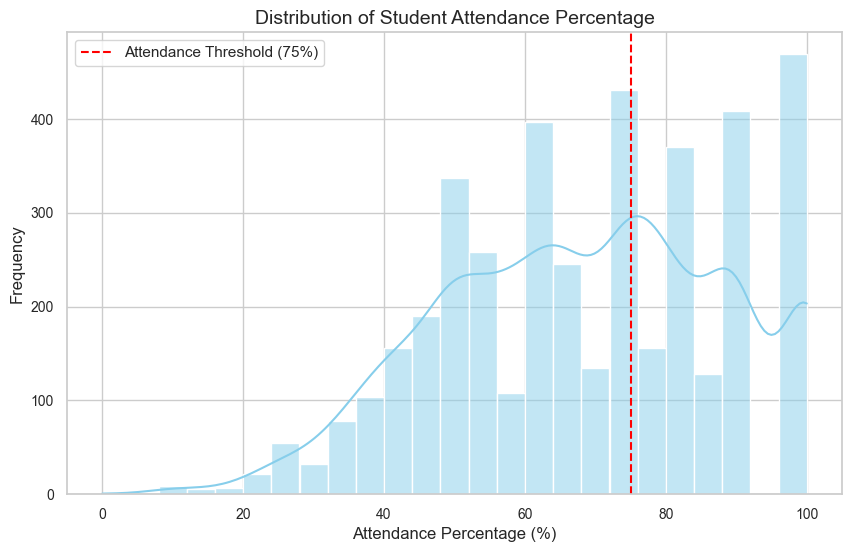

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=att_col, kde=True, bins=25, color='skyblue')
plt.axvline(75, color='red', linestyle='--', linewidth=1.5, label='Attendance Threshold (75%)')
plt.title('Distribution of Student Attendance Percentage')
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(os.path.join(CHARTS_DIR, 'attendance_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

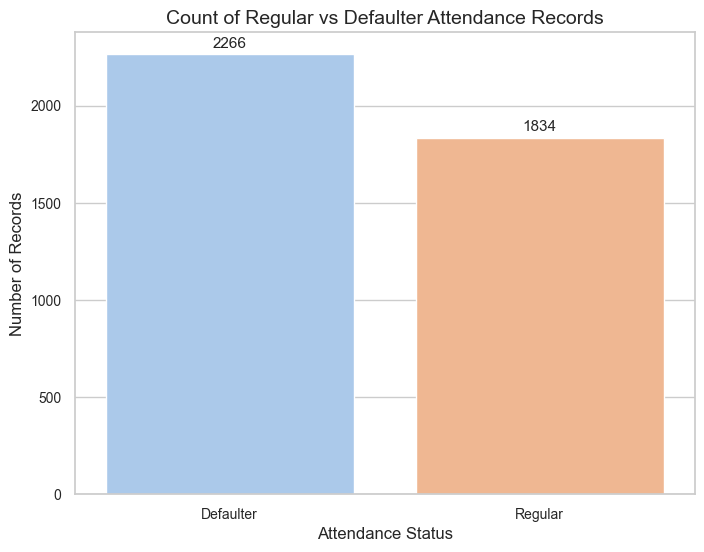

In [11]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Attendance_Status', hue='Attendance_Status', palette='pastel', legend=False)
plt.title('Count of Regular vs Defaulter Attendance Records')
plt.xlabel('Attendance Status')
plt.ylabel('Number of Records')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 20),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig(os.path.join(CHARTS_DIR, 'regular_defaulter_count.png'), dpi=150, bbox_inches='tight')
plt.show()

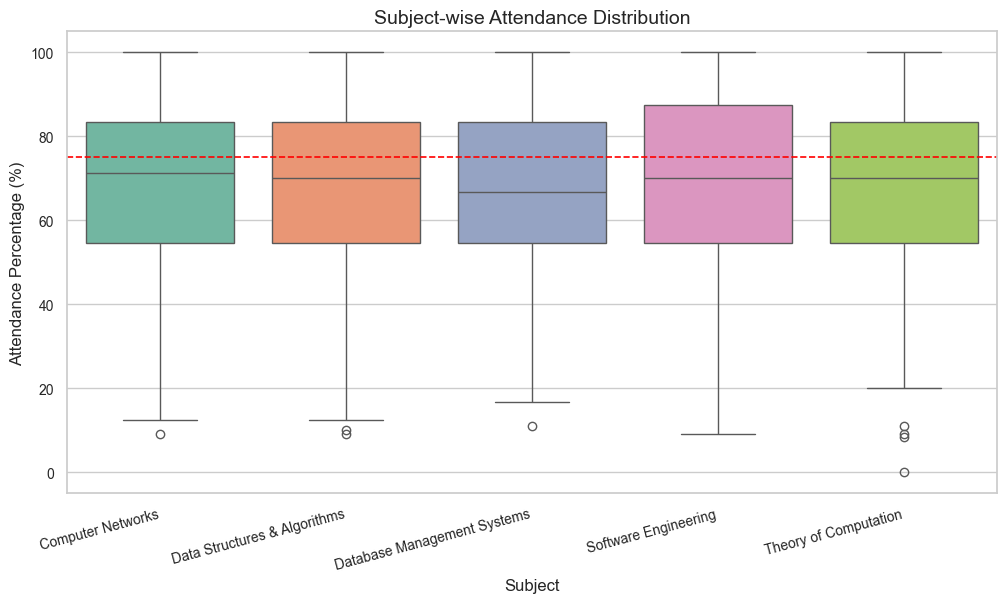

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Subject', y=att_col, hue='Subject', palette='Set2', legend=False)
plt.axhline(75, color='red', linestyle='--', linewidth=1.2, label='Threshold (75%)')
plt.xticks(rotation=15, ha='right')
plt.title('Subject-wise Attendance Distribution')
plt.xlabel('Subject')
plt.ylabel('Attendance Percentage (%)')
plt.savefig(os.path.join(CHARTS_DIR, 'subject_wise_attendance.png'), dpi=150, bbox_inches='tight')
plt.show()

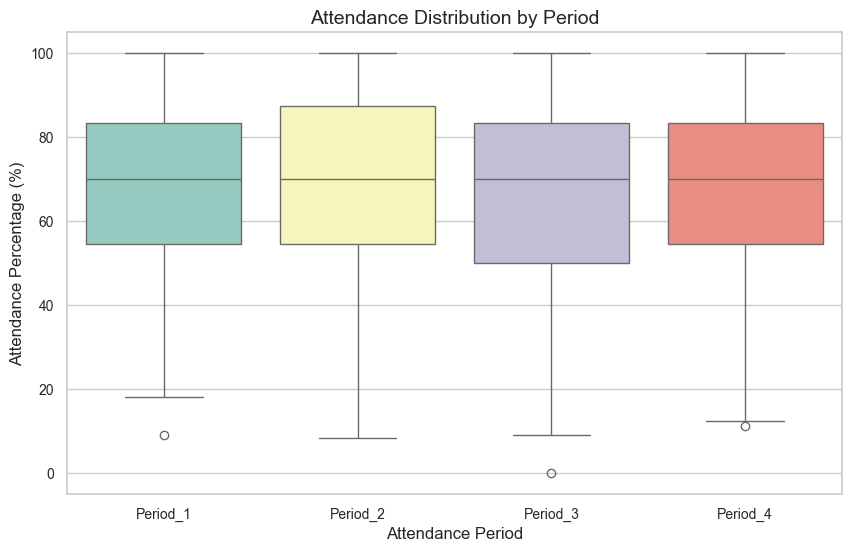

In [13]:
if 'Attendance_Period' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Attendance_Period', y=att_col, hue='Attendance_Period', palette='Set3', legend=False)
    plt.title('Attendance Distribution by Period')
    plt.xlabel('Attendance Period')
    plt.ylabel('Attendance Percentage (%)')
    plt.savefig(os.path.join(CHARTS_DIR, 'attendance_by_period.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping attendance_by_period.png")

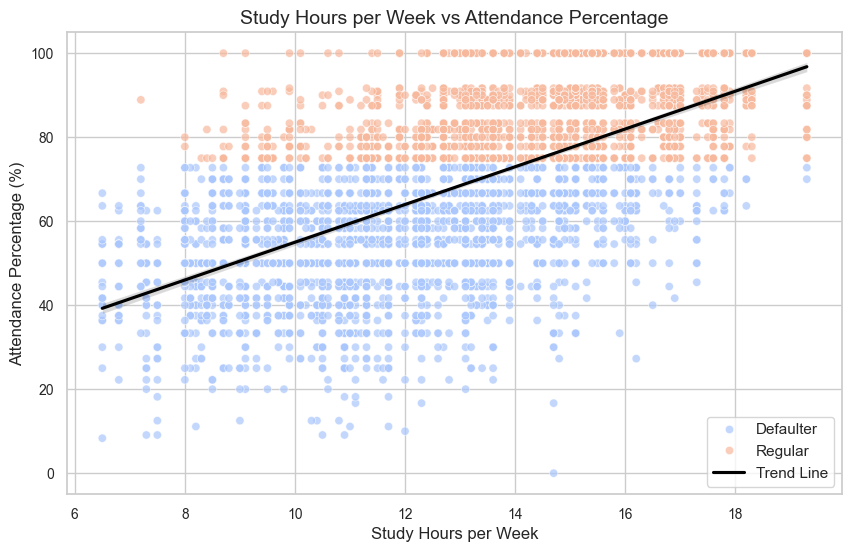

In [14]:
if 'Study_Hours_Per_Week' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Study_Hours_Per_Week', y=att_col, hue='Attendance_Status', palette='coolwarm', alpha=0.7)
    sns.regplot(data=df, x='Study_Hours_Per_Week', y=att_col, scatter=False, color='black', label='Trend Line')
    plt.title('Study Hours per Week vs Attendance Percentage')
    plt.xlabel('Study Hours per Week')
    plt.ylabel('Attendance Percentage (%)')
    plt.legend()
    plt.savefig(os.path.join(CHARTS_DIR, 'study_hours_vs_attendance.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping study_hours_vs_attendance.png")

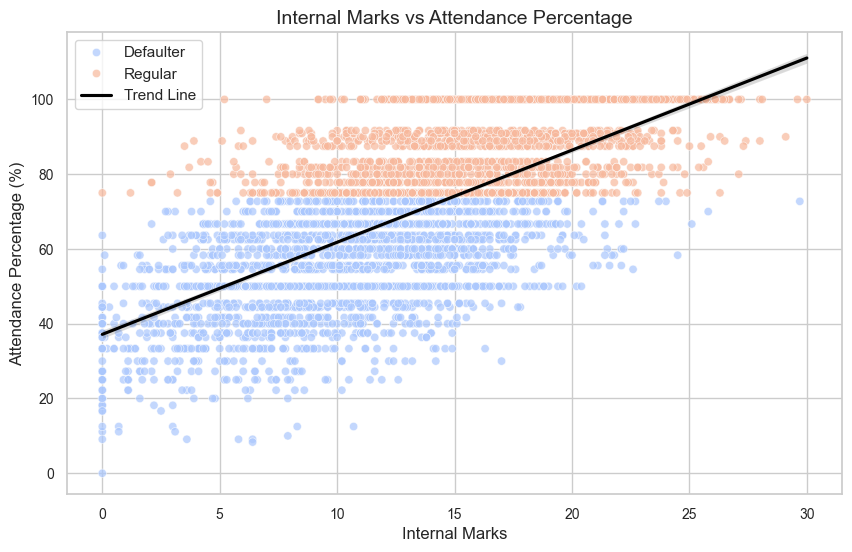

In [15]:
if 'Internal_Marks' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Internal_Marks', y=att_col, hue='Attendance_Status', palette='coolwarm', alpha=0.7)
    sns.regplot(data=df, x='Internal_Marks', y=att_col, scatter=False, color='black', label='Trend Line')
    plt.title('Internal Marks vs Attendance Percentage')
    plt.xlabel('Internal Marks')
    plt.ylabel('Attendance Percentage (%)')
    plt.legend()
    plt.savefig(os.path.join(CHARTS_DIR, 'internal_marks_vs_attendance.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping internal_marks_vs_attendance.png")

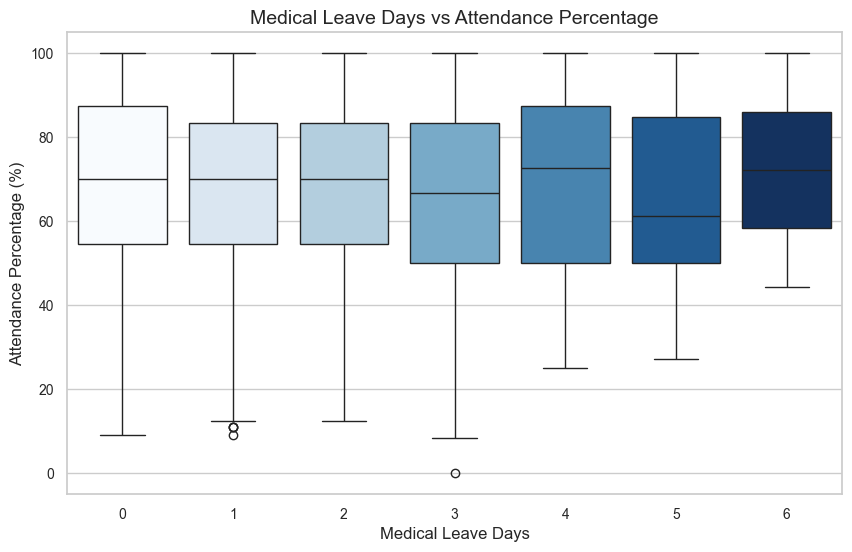

In [16]:
if 'Medical_Leave_Days' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Medical_Leave_Days', y=att_col, hue='Medical_Leave_Days', palette='Blues', legend=False)
    plt.title('Medical Leave Days vs Attendance Percentage')
    plt.xlabel('Medical Leave Days')
    plt.ylabel('Attendance Percentage (%)')
    plt.savefig(os.path.join(CHARTS_DIR, 'medical_leave_vs_attendance.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping medical_leave_vs_attendance.png")

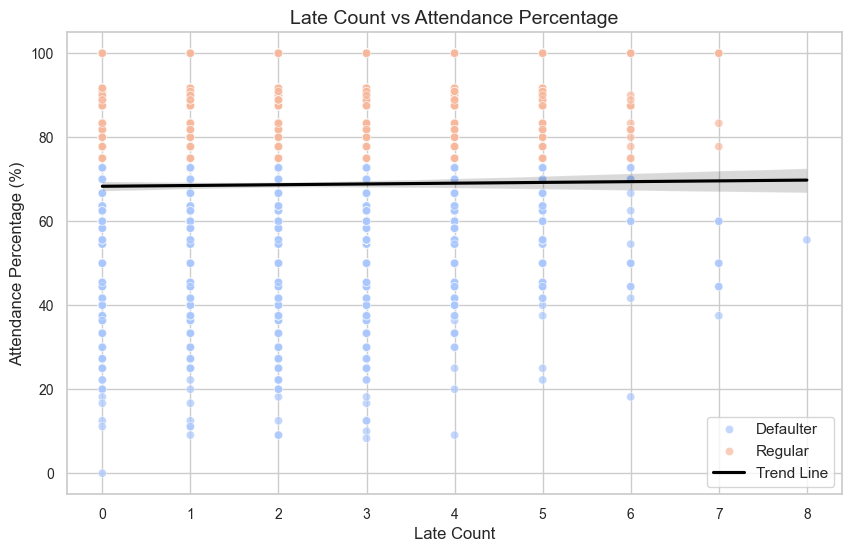

In [17]:
if 'Late_Count' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Late_Count', y=att_col, hue='Attendance_Status', palette='coolwarm', alpha=0.7)
    sns.regplot(data=df, x='Late_Count', y=att_col, scatter=False, color='black', label='Trend Line')
    plt.title('Late Count vs Attendance Percentage')
    plt.xlabel('Late Count')
    plt.ylabel('Attendance Percentage (%)')
    plt.legend()
    plt.savefig(os.path.join(CHARTS_DIR, 'late_count_vs_attendance.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping late_count_vs_attendance.png")

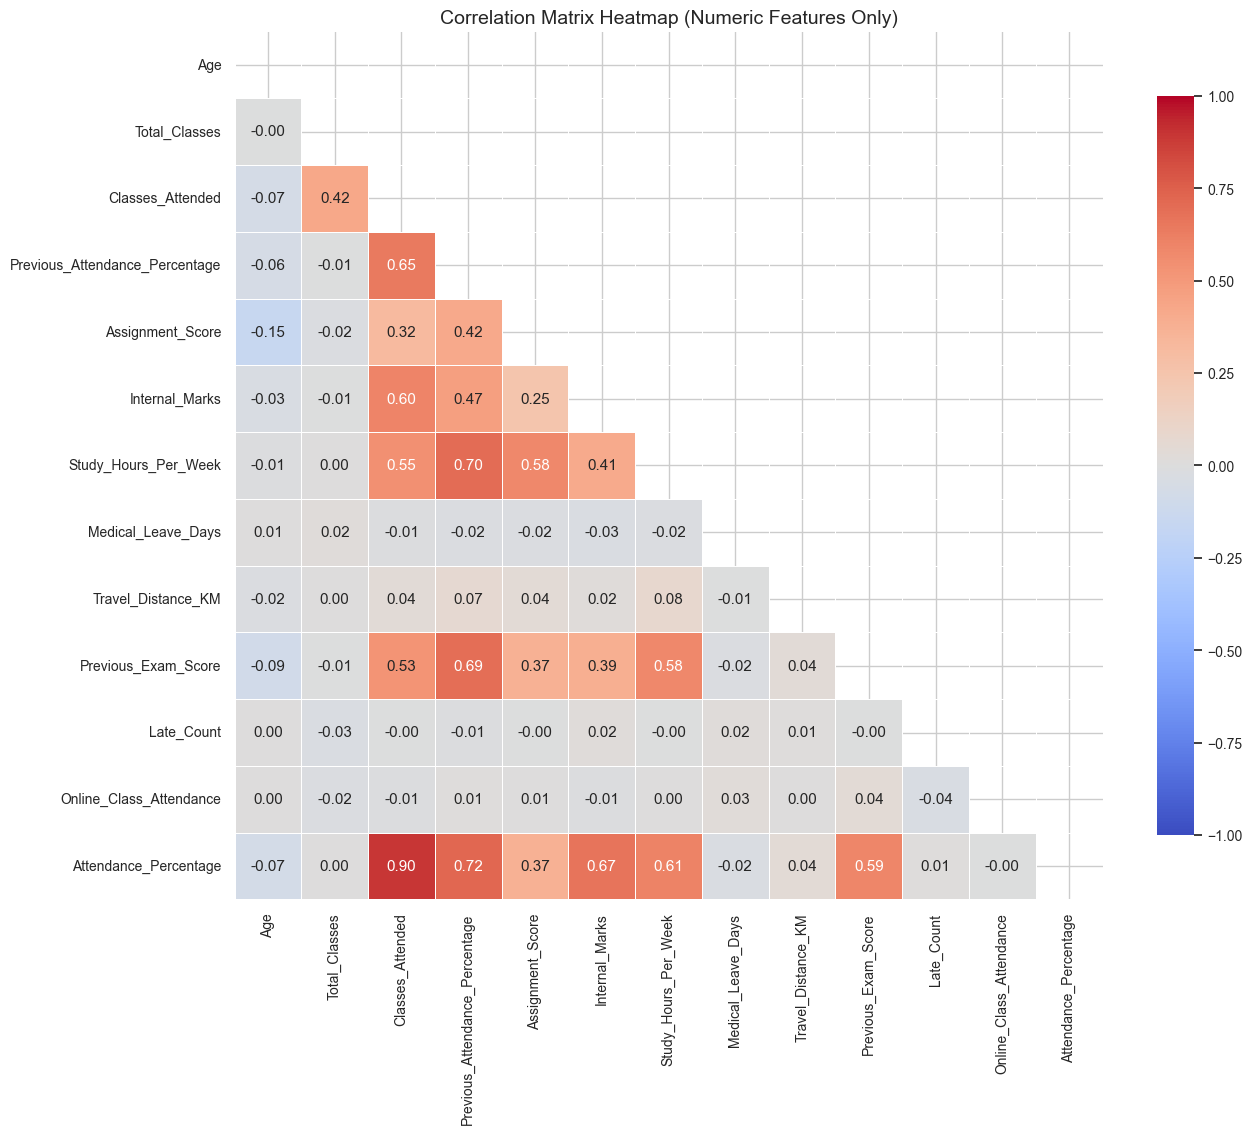

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    plt.figure(figsize=(14, 12))
    corr_matrix = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, cbar_kws={'shrink': .8})
    plt.title('Correlation Matrix Heatmap (Numeric Features Only)')
    plt.savefig(os.path.join(CHARTS_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Skipping correlation_heatmap.png")

## Summary of Findings and Methodology

### 1. Key Metrics
- **Average Attendance:** 68.67%
- **Minimum Attendance:** 0.00%
- **Maximum Attendance:** 100.00%
- **Median Attendance:** 70.00%
- **Defaulter Rate:** 55.27% (2,266 records)
- **Regular Rate:** 44.73% (1,834 records)

### 2. Group Analysis
- **Departmental differences:** Computer Engineering students have an average attendance of **70.89%**, which is slightly higher than MCA students (**67.75%**).
- **Subject-wise distribution:** Attendance is highly consistent across subjects, ranging from **68.38%** (Database Management Systems) to **69.12%** (Software Engineering).
- **Semester & Year differences:** Third Year students (Fifth Semester) show higher average attendance (**70.89%**) than Final Year students (Third Semester) (**67.75%**).

### 3. Key Correlations with Attendance
- **Strongest Positive Associations:**
  - `Previous_Attendance_Percentage` (correlation coefficient = `0.72`)
  - `Internal_Marks` (correlation coefficient = `0.67`)
  - `Study_Hours_Per_Week` (correlation coefficient = `0.61`)
  - `Previous_Exam_Score` (correlation coefficient = `0.59`)
- **Weak or Uncorrelated Features:**
  - `Travel_Distance_KM` (`0.04`)
  - `Late_Count` (`0.01`)
  - `Online_Class_Attendance` (`-0.003`)
  - `Medical_Leave_Days` (`-0.02`)

### ⚠️ Important Methodological Note: Correlation vs. Causation
It is vital to state that **correlation does not imply causation**. While there is a strong positive correlation between `Study_Hours_Per_Week` or `Internal_Marks` and `Attendance_Percentage`:
1. **No direct causal link can be claimed solely from this analysis:** We cannot prove that studying more hours directly *causes* a student to attend more classes, or that attending more classes directly *causes* higher internal marks (there may be confounding factors like motivation, aptitude, or pedagogical style).
2. **Confounding variables:** A student who is highly motivated is likely to study more hours, attend more classes, and get higher marks. The correlation we see is a reflection of this joint relationship.
3. **Synthetic nature:** These relationships are defined by mathematical formulas used to generate the synthetic data and do not represent real-world clinical experiments.